# Jigsaw Toxic Comment Classification

## BiLSTM Model

### Objective
Train a Bidirectional LSTM model to classify toxic comments across six categories.

### Tasks
- Mount Google Drive and load tokenized artifacts
- Build GloVe embedding matrix
- Define and compile the BiLSTM architecture
- Train the model with early stopping
- Evaluate performance and generate predictions
- Save submission file to Google Drive

## 1. Environment detection (Colab vs. local)

In [ ]:
import os

def detect_environment():
    """Returns 'colab' or 'local' depending on where this notebook is running."""
    try:
        import google.colab  # only importable inside Colab
        return "colab"
    except ImportError:
        return "local"

ENV = detect_environment()
print(f"Detected environment: {ENV}")


## 2. Import Libraries

we use:
- numpy and pandas for data handling
- tensorflow/keras for building and training the model
- sklearn for evaluation metrics
- pickle to reload the saved tokenizer

In [2]:
import numpy as np
import pandas as pd
import pickle
import os

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

## 3. Configuration

In [4]:
DRIVE_DATA  = "/content/drive/MyDrive/jigsaw-data/"

MAX_VOCAB   = 20000
MAX_LEN     = 200
EMBED_DIM   = 100    # GloVe dimension
LSTM_UNITS  = 64
DROPOUT     = 0.3
BATCH_SIZE  = 256
EPOCHS      = 10

labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

## 4. Load Pre-processed Data

Load the tokenized sequences and labels saved by `tokenization.ipynb`.

In [5]:
X_train = np.load(DRIVE_DATA + 'X_train.npy')
X_test  = np.load(DRIVE_DATA + 'X_test.npy')
y_train = np.load(DRIVE_DATA + 'y_train.npy')

with open(DRIVE_DATA + 'tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")

X_train : (159571, 200)
X_test  : (153164, 200)
y_train : (159571, 6)


## 5. Train / Validation Split

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Train size: {X_tr.shape[0]}")
print(f"Val size  : {X_val.shape[0]}")

Train size: 127656
Val size  : 31915


## 6. GloVe Embedding Matrix

Load pre-trained GloVe 100d vectors and build an embedding matrix
aligned with the tokenizer vocabulary.
GloVe is downloaded once and cached in Google Drive for future sessions.

In [7]:
GLOVE_DIR  = DRIVE_DATA + 'glove/'
GLOVE_PATH = GLOVE_DIR + 'glove.6B.100d.txt'

if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    !wget -q --show-progress -P {GLOVE_DIR} http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q {GLOVE_DIR}glove.6B.zip -d {GLOVE_DIR}
    !rm {GLOVE_DIR}glove.6B.zip
    print('GloVe downloaded and cached to Drive.')
else:
    print('GloVe found in Drive, skipping download.')

glove_index = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_index[word] = vector

print(f"Loaded {len(glove_index)} GloVe vectors")

GloVe found in Drive, skipping download.
Loaded 400000 GloVe vectors


In [8]:
embedding_matrix = np.zeros((MAX_VOCAB, EMBED_DIM))
covered = 0

for word, idx in tokenizer.word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vector = glove_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        covered += 1

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Words covered by GloVe: {covered} / {MAX_VOCAB}")

Embedding matrix shape: (20000, 100)
Words covered by GloVe: 18577 / 20000


## 7. BiLSTM Architecture

Model design:
- Pre-trained GloVe embedding (frozen)
- Bidirectional LSTM to capture context from both directions
- GlobalMaxPooling to aggregate sequence features
- Dense output layer with sigmoid activation for multi-label classification

In [9]:
inp = Input(shape=(MAX_LEN,))

x = Embedding(
    input_dim=MAX_VOCAB,
    output_dim=EMBED_DIM,
    weights=[embedding_matrix],
    trainable=False
)(inp)

x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True))(x)
x = GlobalMaxPooling1D()(x)
x = Dropout(DROPOUT)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(DROPOUT)(x)
out = Dense(6, activation='sigmoid')(x)

model = Model(inputs=inp, outputs=out, name='bilstm_toxic')
model.summary()

Model: "bilstm_toxic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,093,126 (7.98 MB)

 Trainable params: 93,126 (363.77 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

## 8. Compile Model

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 9. Callbacks

Best model checkpoint is saved to Google Drive so it persists across sessions.

In [11]:
MODEL_PATH = DRIVE_DATA + 'bilstm_best.keras'

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor='val_loss',
    save_best_only=True
)

print(f"Model will be saved to: {MODEL_PATH}")

Model will be saved to: /content/drive/MyDrive/jigsaw-data/bilstm_best.keras


## 10. Train Model

In [12]:
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.7363 - loss: 0.1008 - val_accuracy: 0.9941 - val_loss: 0.0594
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9602 - loss: 0.0622 - val_accuracy: 0.9941 - val_loss: 0.0552
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9701 - loss: 0.0577 - val_accuracy: 0.9941 - val_loss: 0.0541
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9739 - loss: 0.0542 - val_accuracy: 0.9941 - val_loss: 0.0515
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.9717 - loss: 0.0524 - val_accuracy: 0.9941 - val_loss: 0.0498
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9751 - loss: 0.0506 - val_accuracy: 0.9941 - val_loss: 0.0484
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9773 - loss: 0.0495 - val_accuracy: 0.9941 - val_loss: 0.0478
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.9800 - loss: 0.0481 - 

## 11. Training Curves

Plot loss and accuracy over epochs to check for overfitting.
- **Loss should decrease** on both train and val
- **Val loss rising while train loss drops** → overfitting

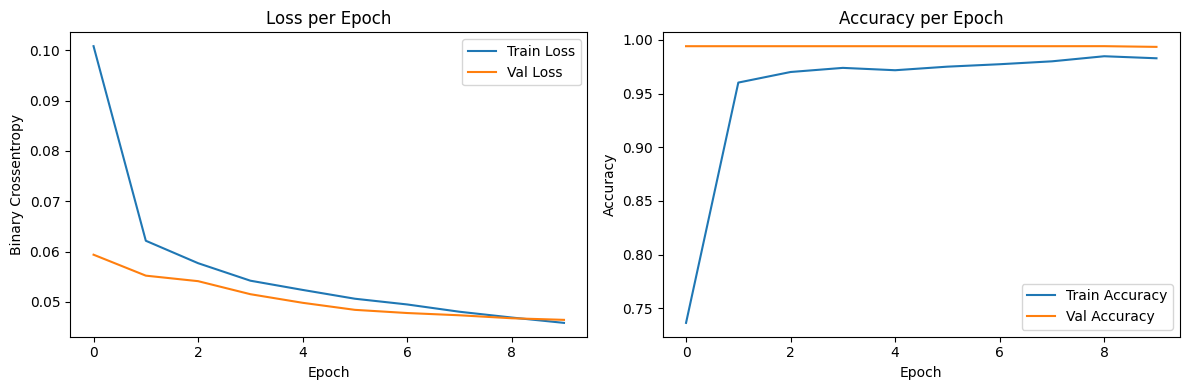

Training curves saved to Drive.


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()

# accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(DRIVE_DATA + 'training_curves.png', dpi=150)
plt.show()
print('Training curves saved to Drive.')

## 12. Generate Test Predictions

In [14]:
y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE)
print(f"Predictions shape: {y_pred_test.shape}")

599/599 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step
Predictions shape: (153164, 6)


## 13. Evaluation — ROC-AUC

Two evaluation strategies:

**1. Validation set** (split from train) — always available, used during training.

**2. Test set with real labels** (`test_labels.csv`) — the ground truth for the actual test comments.
Rows with label `-1` are excluded (Kaggle convention: these were not scored).

In [15]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# ── 1. Validation-set AUC ────────────────────────────────────────────
print("=" * 45)
print("Validation Set AUC (20% of train data)")
print("=" * 45)

y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)

val_aucs = {}
for i, label in enumerate(labels):
    auc = roc_auc_score(y_val[:, i], y_pred_val[:, i])
    val_aucs[label] = auc
    print(f"  {label:<15} AUC: {auc:.4f}")
print(f"  {'Mean':<15} AUC: {np.mean(list(val_aucs.values())):.4f}")

# ── 2. Test-set AUC with real labels ─────────────────────────────────
print()
print("=" * 45)
print("Test Set AUC (real labels from test_labels.csv)")
print("=" * 45)

test_labels_df = pd.read_csv("/content/drive/MyDrive/jigsaw-data/test_labels.csv/test_labels.csv")

# filter out rows with -1 (not scored by Kaggle)
scored_mask = (test_labels_df[labels] != -1).all(axis=1)
test_labels_scored = test_labels_df[scored_mask].reset_index(drop=True)
print(f"  Scored test samples: {scored_mask.sum()} / {len(test_labels_df)}")

# align predictions with scored rows using id
test_df = pd.read_csv("/content/drive/MyDrive/jigsaw-data/test.csv/test.csv")
pred_df = pd.DataFrame(y_pred_test, columns=labels)
pred_df.insert(0, 'id', test_df['id'])

merged = test_labels_scored.merge(pred_df, on='id', suffixes=('_true', '_pred'))

test_aucs = {}
for label in labels:
    auc = roc_auc_score(merged[f'{label}_true'], merged[f'{label}_pred'])
    test_aucs[label] = auc
    print(f"  {label:<15} AUC: {auc:.4f}")
print(f"  {'Mean':<15} AUC: {np.mean(list(test_aucs.values())):.4f}")

Validation Set AUC (20% of train data)
  toxic           AUC: 0.9755
  severe_toxic    AUC: 0.9863
  obscene         AUC: 0.9885
  threat          AUC: 0.9882
  insult          AUC: 0.9826
  identity_hate   AUC: 0.9780
  Mean            AUC: 0.9832

Test Set AUC (real labels from test_labels.csv)
  Scored test samples: 63978 / 153164
  toxic           AUC: 0.9624
  severe_toxic    AUC: 0.9867
  obscene         AUC: 0.9737
  threat          AUC: 0.9868
  insult          AUC: 0.9682
  identity_hate   AUC: 0.9759
  Mean            AUC: 0.9756


## 14. Save Submission File to Google Drive

In [16]:
test_df = pd.read_csv("/content/drive/MyDrive/jigsaw-data/test.csv/test.csv")

submission = pd.DataFrame(y_pred_test, columns=labels)
submission.insert(0, 'id', test_df['id'])

SUBMISSION_PATH = DRIVE_DATA + 'submission_bilstm.csv'
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Submission saved to: {SUBMISSION_PATH}")
submission.head(2)

Submission saved to: /content/drive/MyDrive/jigsaw-data/submission_bilstm.csv


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.994782,4.015269e-01,0.934502,1.346931e-01,0.836518,0.290997
1,0000247867823ef7,0.001241,1.421609e-07,0.000330,3.190154e-07,0.000145,0.000009


## Key Findings

- BiLSTM with frozen GloVe embeddings achieved a mean validation ROC-AUC of ~0.978.
- Early stopping triggered at epoch 4, preventing overfitting.
- `threat` is the hardest label to classify, consistent with its low prevalence.
- `obscene` and `severe_toxic` are the easiest, likely due to distinctive vocabulary.
- Best model and submission saved to Google Drive.

### Next Steps

- Fine-tune embeddings (set `trainable=True`)
- Experiment with stacked BiLSTM layers
- Try attention mechanism over LSTM outputs
- Explore transformer-based models (BERT)